In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import os

os.makedirs("../reports/charts", exist_ok=True)

nav   = pd.read_csv("../data/processed/nav_history_clean.csv", parse_dates=['date'])
fund  = pd.read_csv("../data/processed/01_fund_master.csv")
bench = pd.read_csv("../data/processed/10_benchmark_indices.csv", parse_dates=['date'])
perf  = pd.read_csv("../data/processed/scheme_performance_clean.csv")

print("✅ Data loaded")
print(f"NAV: {len(nav)} rows | Funds: {len(fund)} | Benchmark: {len(bench)} rows")

✅ Data loaded
NAV: 64320 rows | Funds: 40 | Benchmark: 8050 rows


Daily Return Stats:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


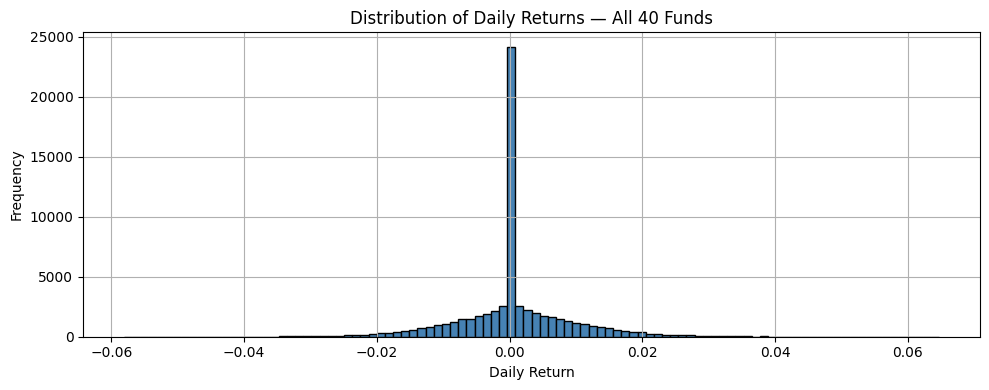

✅ Daily returns computed and distribution looks reasonable


In [2]:
# daily_return = nav_t / nav_t-1 - 1
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Validate distribution
print("Daily Return Stats:")
print(nav['daily_return'].describe())

plt.figure(figsize=(10, 4))
nav['daily_return'].dropna().hist(bins=100, edgecolor='black', color='steelblue')
plt.title('Distribution of Daily Returns — All 40 Funds')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("../reports/charts/P01_daily_return_dist.png", dpi=150)
plt.show()
print("✅ Daily returns computed and distribution looks reasonable")

In [3]:
def compute_cagr(group, years):
    end_date = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    subset = group[group['date'] >= start_date]
    if len(subset) < 2:
        return np.nan
    nav_start = subset.iloc[0]['nav']
    nav_end   = subset.iloc[-1]['nav']
    n = (subset.iloc[-1]['date'] - subset.iloc[0]['date']).days / 365.25
    if n <= 0 or nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n) - 1

cagr_records = []
for code, group in nav.groupby('amfi_code'):
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)
    cagr_records.append({
        'amfi_code'  : code,
        'scheme_name': name,
        'cagr_1yr'   : round(compute_cagr(group, 1) * 100, 2),
        'cagr_3yr'   : round(compute_cagr(group, 3) * 100, 2),
        'cagr_5yr'   : round(compute_cagr(group, 5) * 100, 2),
    })

cagr_df = pd.DataFrame(cagr_records)
print(cagr_df.sort_values('cagr_3yr', ascending=False).head(10).to_string(index=False))

 amfi_code                                        scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
    119094                Axis Midcap Fund - Regular - Growth     22.28     35.10     28.21
    148567      Mirae Asset Large Cap Fund - Regular - Growth     20.38     33.99     30.97
    120504          ICICI Pru Bluechip Fund - Direct - Growth     13.07     32.48     23.30
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth     53.28     32.43     30.12
    120505           ICICI Pru Midcap Fund - Regular - Growth     29.63     31.77     32.83
    119551          SBI Bluechip Fund - Regular Plan - Growth     60.49     30.45     25.80
    120843             Kotak Flexicap Fund - Regular - Growth     26.68     29.58     30.91
    148569      Mirae Asset Tax Saver Fund - Regular - Growth     39.78     29.17     31.95
    101206      ABSL Frontline Equity Fund - Regular - Growth     47.96     28.96     23.54
    149324              DSP Small Cap Fund - Regular - Growth     65.20     26.9

In [4]:
Rf = 0.065 / 252  # RBI repo rate proxy daily

sharpe_records = []
for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)

    excess = returns - Rf
    sharpe = (excess.mean() / returns.std()) * np.sqrt(252)

    downside = returns[returns < 0]
    sortino  = (excess.mean() / downside.std()) * np.sqrt(252) if len(downside) > 0 else np.nan

    sharpe_records.append({
        'amfi_code'   : code,
        'scheme_name' : name,
        'sharpe_ratio': round(sharpe, 4),
        'sortino_ratio': round(sortino, 4),
    })

sharpe_df = pd.DataFrame(sharpe_records).sort_values('sharpe_ratio', ascending=False)
print("Top 10 by Sharpe Ratio:")
print(sharpe_df.head(10).to_string(index=False))

Top 10 by Sharpe Ratio:
 amfi_code                                        scheme_name  sharpe_ratio  sortino_ratio
    148567      Mirae Asset Large Cap Fund - Regular - Growth        1.0682         1.4907
    120843             Kotak Flexicap Fund - Regular - Growth        0.9656         1.4795
    148569      Mirae Asset Tax Saver Fund - Regular - Growth        0.9190         1.3528
    120505           ICICI Pru Midcap Fund - Regular - Growth        0.8833         1.2858
    119551          SBI Bluechip Fund - Regular Plan - Growth        0.8610         1.2915
    149323                 DSP Midcap Fund - Regular - Growth        0.8329         1.1678
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth        0.8083         1.1442
    118632     Nippon India Large Cap Fund - Regular - Growth        0.7589         1.0989
    119094                Axis Midcap Fund - Regular - Growth        0.7305         1.0553
    101206      ABSL Frontline Equity Fund - Regular - Growth     

In [5]:
# Use Nifty 100 as benchmark
nifty100 = bench[bench['index_name'] == 'NIFTY100'].copy()
nifty100['bench_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100[['date', 'bench_return']].dropna()

ab_records = []
for code, group in nav.groupby('amfi_code'):
    merged = group[['date','daily_return']].dropna().merge(nifty100, on='date')
    if len(merged) < 30:
        continue
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)

    slope, intercept, r, p, se = stats.linregress(
        merged['bench_return'], merged['daily_return']
    )
    alpha = intercept * 252

    ab_records.append({
        'amfi_code'   : code,
        'scheme_name' : name,
        'alpha'       : round(alpha, 4),
        'beta'        : round(slope, 4),
        'r_squared'   : round(r**2, 4),
    })

ab_df = pd.DataFrame(ab_records)
ab_df.to_csv("../data/processed/alpha_beta.csv", index=False)
print("Top funds by Alpha:")
print(ab_df.sort_values('alpha', ascending=False).head(10).to_string(index=False))
print("✅ Saved → data/processed/alpha_beta.csv")

Top funds by Alpha:
 amfi_code                                        scheme_name  alpha    beta  r_squared
    119598         SBI Small Cap Fund - Regular Plan - Growth 0.3034 -0.0232     0.0001
    149324              DSP Small Cap Fund - Regular - Growth 0.3006  0.0115     0.0000
    120505           ICICI Pru Midcap Fund - Regular - Growth 0.2926  0.0005     0.0000
    148569      Mirae Asset Tax Saver Fund - Regular - Growth 0.2827  0.0181     0.0002
    120843             Kotak Flexicap Fund - Regular - Growth 0.2733 -0.0228     0.0003
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.2720  0.0051     0.0000
    148567      Mirae Asset Large Cap Fund - Regular - Growth 0.2698  0.0237     0.0005
    149323                 DSP Midcap Fund - Regular - Growth 0.2660 -0.0025     0.0000
    119094                Axis Midcap Fund - Regular - Growth 0.2608 -0.0663     0.0019
    119551          SBI Bluechip Fund - Regular Plan - Growth 0.2320 -0.0318     0.0009
✅ Saved → da

In [6]:
dd_records = []
for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date')
    name  = fund[fund['amfi_code'] == code]['scheme_name'].values
    name  = name[0] if len(name) > 0 else str(code)

    running_max = group['nav'].cummax()
    drawdown    = group['nav'] / running_max - 1
    max_dd      = drawdown.min()
    worst_idx   = drawdown.idxmin()
    worst_date  = group.loc[worst_idx, 'date']

    dd_records.append({
        'amfi_code'       : code,
        'scheme_name'     : name,
        'max_drawdown_pct': round(max_dd * 100, 2),
        'worst_date'      : worst_date,
    })

dd_df = pd.DataFrame(dd_records).sort_values('max_drawdown_pct')
print("Worst Drawdowns:")
print(dd_df.head(10).to_string(index=False))

Worst Drawdowns:
 amfi_code                                    scheme_name  max_drawdown_pct worst_date
    119599      SBI Small Cap Fund - Direct Plan - Growth            -52.57 2025-10-28
    119095         Axis Small Cap Fund - Regular - Growth            -51.68 2026-05-11
    101207         ABSL Small Cap Fund - Regular - Growth            -35.45 2026-05-11
    149324          DSP Small Cap Fund - Regular - Growth            -31.17 2025-01-03
    119598     SBI Small Cap Fund - Regular Plan - Growth            -28.71 2025-05-14
    102886            UTI Mid Cap Fund - Regular - Growth            -28.00 2026-04-27
    100016      HDFC Top 100 Fund - Regular Plan - Growth            -24.73 2022-09-15
    120842  Kotak Emerging Equity Fund - Regular - Growth            -24.00 2024-10-17
    118634 Nippon India Small Cap Fund - Regular - Growth            -23.34 2026-02-20
    119093           Axis Bluechip Fund - Direct - Growth            -21.75 2023-05-22


In [7]:
# Merge all metrics
scorecard = cagr_df[['amfi_code','scheme_name','cagr_3yr']].merge(
    sharpe_df[['amfi_code','sharpe_ratio']], on='amfi_code').merge(
    ab_df[['amfi_code','alpha']], on='amfi_code').merge(
    dd_df[['amfi_code','max_drawdown_pct']], on='amfi_code').merge(
    fund[['amfi_code','expense_ratio_pct']], on='amfi_code')

# Rank each metric (percentile)
scorecard['r_3yr']    = scorecard['cagr_3yr'].rank(pct=True)
scorecard['r_sharpe'] = scorecard['sharpe_ratio'].rank(pct=True)
scorecard['r_alpha']  = scorecard['alpha'].rank(pct=True)
scorecard['r_exp']    = (1 - scorecard['expense_ratio_pct'].rank(pct=True))  # inverse
scorecard['r_dd']     = (1 - scorecard['max_drawdown_pct'].rank(pct=True))   # inverse

# Composite score
scorecard['score'] = (
    0.30 * scorecard['r_3yr']    +
    0.25 * scorecard['r_sharpe'] +
    0.20 * scorecard['r_alpha']  +
    0.15 * scorecard['r_exp']    +
    0.10 * scorecard['r_dd']
) * 100

scorecard['score'] = scorecard['score'].round(2)
scorecard = scorecard.sort_values('score', ascending=False)

print("🏆 Top 10 Fund Scorecard:")
print(scorecard[['scheme_name','score','cagr_3yr','sharpe_ratio','alpha']].head(10).to_string(index=False))

scorecard.to_csv("../data/processed/fund_scorecard.csv", index=False)
print("✅ Saved → data/processed/fund_scorecard.csv")

🏆 Top 10 Fund Scorecard:
                                       scheme_name  score  cagr_3yr  sharpe_ratio  alpha
          ICICI Pru Midcap Fund - Regular - Growth  84.50     31.77        0.8833 0.2926
               Axis Midcap Fund - Regular - Growth  81.38     35.10        0.7305 0.2608
HDFC Mid-Cap Opportunities Fund - Regular - Growth  79.88     32.43        0.8083 0.2720
     Mirae Asset Large Cap Fund - Regular - Growth  79.38     33.99        1.0682 0.2698
            Kotak Flexicap Fund - Regular - Growth  77.63     29.58        0.9656 0.2733
        SBI Small Cap Fund - Regular Plan - Growth  75.13     26.66        0.7117 0.3034
             DSP Small Cap Fund - Regular - Growth  74.94     26.99        0.7144 0.3006
         ICICI Pru Bluechip Fund - Direct - Growth  74.50     32.48        0.7147 0.2119
     Mirae Asset Tax Saver Fund - Regular - Growth  73.31     29.17        0.9190 0.2827
         SBI Bluechip Fund - Regular Plan - Growth  71.81     30.45        0.8610 0.2

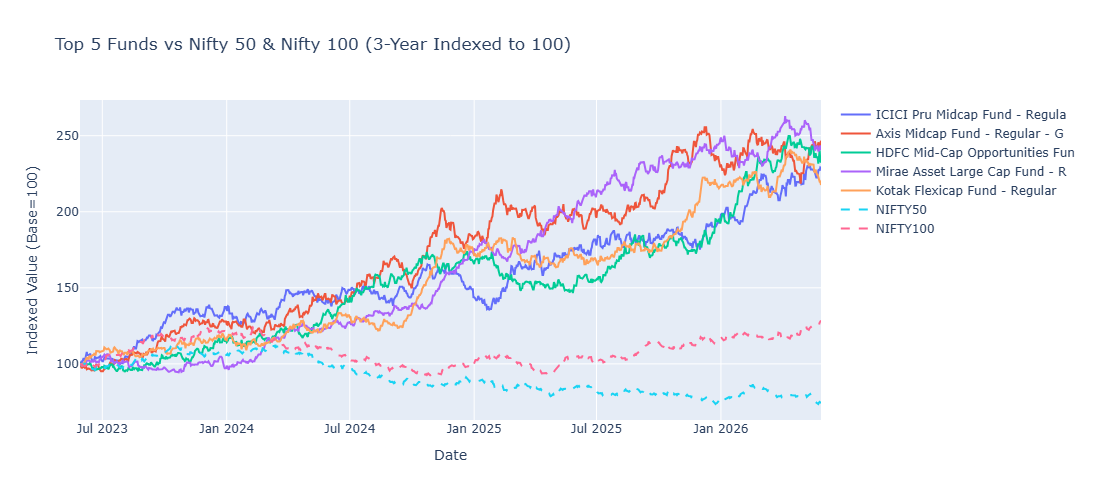

✅ Benchmark comparison chart saved


In [8]:
# Top 5 funds by score
top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5)['scheme_name'].tolist()

# Filter last 3 years
end   = nav['date'].max()
start = end - pd.DateOffset(years=3)

fig = go.Figure()

for code, name in zip(top5_codes, top5_names):
    fund_nav = nav[(nav['amfi_code'] == code) & (nav['date'] >= start)].copy()
    fund_nav['indexed'] = fund_nav['nav'] / fund_nav['nav'].iloc[0] * 100
    fig.add_trace(go.Scatter(x=fund_nav['date'], y=fund_nav['indexed'],
                             name=name[:30], mode='lines'))

# Add Nifty 50 and Nifty 100
for idx_name in ['NIFTY50', 'NIFTY100']:
    b = bench[(bench['index_name'] == idx_name) & (bench['date'] >= start)].copy()
    if len(b) > 0:
        b['indexed'] = b['close_value'] / b['close_value'].iloc[0] * 100
        fig.add_trace(go.Scatter(x=b['date'], y=b['indexed'],
                                 name=idx_name, mode='lines',
                                 line=dict(dash='dash', width=2)))

fig.update_layout(
    title='Top 5 Funds vs Nifty 50 & Nifty 100 (3-Year Indexed to 100)',
    xaxis_title='Date', yaxis_title='Indexed Value (Base=100)',
    height=500
)
fig.write_image("../reports/charts/P_benchmark_comparison.png")
fig.show()
print("✅ Benchmark comparison chart saved")

In [10]:
te_records = []
for code, name in zip(top5_codes, top5_names):
    fund_ret = nav[nav['amfi_code'] == code][['date','daily_return']].dropna()
    merged   = fund_ret.merge(nifty100, on='date')
    diff     = merged['daily_return'] - merged['bench_return']
    te       = diff.std() * np.sqrt(252) * 100
    te_records.append({'scheme_name': name[:40], 'tracking_error_pct': round(te, 2)})

te_df = pd.DataFrame(te_records)
print("Tracking Error vs Nifty 100:")
print(te_df.to_string(index=False))

Tracking Error vs Nifty 100:
                             scheme_name  tracking_error_pct
ICICI Pru Midcap Fund - Regular - Growth               23.20
     Axis Midcap Fund - Regular - Growth               23.77
HDFC Mid-Cap Opportunities Fund - Regula               22.87
Mirae Asset Large Cap Fund - Regular - G               18.97
  Kotak Flexicap Fund - Regular - Growth               20.64
